# GPyTorch Regression Tutorial (GPU)

(This notebook is the same as the [simple GP regression tutorial](../01_Exact_GPs/Simple_GP_Regression.ipynb) notebook, but does all computations on a GPU for acceleration.
Check out the [multi-GPU tutorial](./Simple_MultiGPU_GP_Regression.ipynb) if you have large datasets that needs multiple GPUs!) 

## Introduction

In this notebook, we demonstrate many of the design features of GPyTorch using the simplest example, training an RBF kernel Gaussian process on a simple function. We'll be modeling the function

$$
\begin{align}
  y &= \sin(2\pi x) + \epsilon \\ 
  \epsilon &\sim \mathcal{N}(0, 0.04) 
\end{align}
$$

with 100 training examples, and testing on 51 test examples.

In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

### Set up training data

In the next cell, we set up the training data for this example. We'll be using 100 regularly spaced points on [0,1] which we evaluate the function on and add Gaussian noise to get the training labels.

In [2]:
# Training data is 100 points in [0,1] inclusive regularly spaced
train_x = torch.linspace(0, 1, 100)
# True function is sin(2*pi*x) with Gaussian noise
train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

### Setting up the model

See [the simple GP regression tutorial](../01_Exact_GPs/Simple_GP_Regression.ipynb) for a detailed explanation for all the terms.

In [3]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

## Using the GPU

To do computations on the GPU, we need to put our data and model onto the GPU. (This requires PyTorch with CUDA).

In [4]:
train_x = train_x.to("mps")
train_y = train_y.to("mps")
model = model.to("mps")
likelihood = likelihood.to("mps")

That's it! All the training code is the same as in [the simple GP regression tutorial](../01_Exact_GPs/Simple_GP_Regression.ipynb).

### Training the model

In [5]:
# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 50
for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/50 - Loss: 0.963   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 0.933   lengthscale: 0.644   noise: 0.644
Iter 3/50 - Loss: 0.900   lengthscale: 0.598   noise: 0.598
Iter 4/50 - Loss: 0.862   lengthscale: 0.555   noise: 0.554
Iter 5/50 - Loss: 0.819   lengthscale: 0.514   noise: 0.513
Iter 6/50 - Loss: 0.770   lengthscale: 0.476   noise: 0.474
Iter 7/50 - Loss: 0.716   lengthscale: 0.440   noise: 0.437
Iter 8/50 - Loss: 0.660   lengthscale: 0.405   noise: 0.402
Iter 9/50 - Loss: 0.607   lengthscale: 0.373   noise: 0.369
Iter 10/50 - Loss: 0.559   lengthscale: 0.343   noise: 0.339
Iter 11/50 - Loss: 0.516   lengthscale: 0.316   noise: 0.310
Iter 12/50 - Loss: 0.478   lengthscale: 0.292   noise: 0.283


Iter 13/50 - Loss: 0.442   lengthscale: 0.272   noise: 0.259
Iter 14/50 - Loss: 0.408   lengthscale: 0.255   noise: 0.236
Iter 15/50 - Loss: 0.375   lengthscale: 0.241   noise: 0.215
Iter 16/50 - Loss: 0.342   lengthscale: 0.230   noise: 0.196
Iter 17/50 - Loss: 0.310   lengthscale: 0.221   noise: 0.178
Iter 18/50 - Loss: 0.279   lengthscale: 0.214   noise: 0.162
Iter 19/50 - Loss: 0.248   lengthscale: 0.209   noise: 0.147
Iter 20/50 - Loss: 0.218   lengthscale: 0.206   noise: 0.134
Iter 21/50 - Loss: 0.189   lengthscale: 0.204   noise: 0.121
Iter 22/50 - Loss: 0.161   lengthscale: 0.204   noise: 0.110
Iter 23/50 - Loss: 0.134   lengthscale: 0.205   noise: 0.100
Iter 24/50 - Loss: 0.109   lengthscale: 0.207   noise: 0.091
Iter 25/50 - Loss: 0.086   lengthscale: 0.209   noise: 0.083
Iter 26/50 - Loss: 0.065   lengthscale: 0.213   noise: 0.076
Iter 27/50 - Loss: 0.046   lengthscale: 0.218   noise: 0.069
Iter 28/50 - Loss: 0.030   lengthscale: 0.223   noise: 0.063
Iter 29/50 - Loss: 0.016

Iter 33/50 - Loss: -0.009   lengthscale: 0.258   noise: 0.043
Iter 34/50 - Loss: -0.008   lengthscale: 0.266   noise: 0.041
Iter 35/50 - Loss: -0.006   lengthscale: 0.273   noise: 0.038
Iter 36/50 - Loss: -0.003   lengthscale: 0.280   noise: 0.037
Iter 37/50 - Loss: 0.001   lengthscale: 0.286   noise: 0.035
Iter 38/50 - Loss: 0.006   lengthscale: 0.292   noise: 0.034
Iter 39/50 - Loss: 0.010   lengthscale: 0.296   noise: 0.033
Iter 40/50 - Loss: 0.012   lengthscale: 0.299   noise: 0.033
Iter 41/50 - Loss: 0.014   lengthscale: 0.301   noise: 0.032
Iter 42/50 - Loss: 0.015   lengthscale: 0.302   noise: 0.032
Iter 43/50 - Loss: 0.014   lengthscale: 0.302   noise: 0.032
Iter 44/50 - Loss: 0.012   lengthscale: 0.300   noise: 0.033
Iter 45/50 - Loss: 0.009   lengthscale: 0.298   noise: 0.033
Iter 46/50 - Loss: 0.006   lengthscale: 0.296   noise: 0.034
Iter 47/50 - Loss: 0.003   lengthscale: 0.293   noise: 0.035
Iter 48/50 - Loss: -0.000   lengthscale: 0.290   noise: 0.035
Iter 49/50 - Loss: 

### Make predictions with the model

First, we need to make some test data, and then throw it onto the GPU

In [6]:
test_x = torch.linspace(0, 1, 51).to("mps")

Now the rest of the code follows [the simple GP regression tutorial](../01_Exact_GPs/Simple_GP_Regression.ipynb).

In [7]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    mean = observed_pred.mean
    lower, upper = observed_pred.confidence_region()

For plotting, we're going to grab the data from the GPU and put it back on the CPU.
We can accomplish this with the `.cpu()` function.

In [8]:
mean = mean.cpu()
lower = lower.cpu()
upper = upper.cpu()

train_x = train_x.cpu()
train_y = train_y.cpu()
test_x = test_x.cpu()

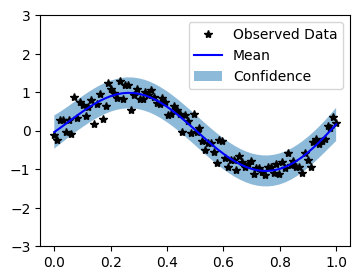

In [9]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])